In [1]:
import warnings
warnings.filterwarnings('ignore')

import torch
import tonic
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

dtype = torch.float
# device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device = torch.device("cpu")
transform = tonic.transforms.Compose(
    [
        tonic.transforms.Downsample(spatial_factor=32/34),
        tonic.transforms.ToFrame(
            sensor_size=(32, 32, 2),
            time_window=10_000,
        ),
    ]
)

train_set = tonic.datasets.NMNIST(save_to=r'path\to\data', train=True, transform=transform)
test_set = tonic.datasets.NMNIST(save_to=r'path\to\data', train=False, transform=transform)

n_total = len(train_set)
n_train = int(0.95 * n_total)          
n_val = n_total - n_train             

train_set, val_set = random_split(
    train_set,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)  
)

print(f"Train samples:      {len(train_set)}")
print(f"Validation samples: {len(val_set)}")
print(f"Test samples:       {len(test_set)}")

Train samples:      57000
Validation samples: 3000
Test samples:       10000


In [10]:
batch_size = 64
trainloader = DataLoader(train_set, batch_size=batch_size, shuffle=True, drop_last = True, collate_fn = tonic.collation.PadTensors(batch_first=True))
valloader = DataLoader(val_set, batch_size=batch_size, shuffle=True, drop_last = True, collate_fn = tonic.collation.PadTensors(batch_first=True))
testloader = DataLoader(test_set, batch_size=batch_size, shuffle=True, drop_last = True, collate_fn = tonic.collation.PadTensors(batch_first=True))

for data, targets in (trainloader):
    print(data.shape)
    break

torch.Size([64, 31, 2, 32, 32])


- 64 = batch size
- 31 = time steps (variable, padded to longest in batch) 
- 2 = polarities (positive + negative) 
- 32, 32 = spatial dimensions 

In [2]:
def accuracy(model, dataLoader, dataLoaderName='Test'):
    total   = 0
    correct = 0
    y_pred  = []
    y_true  = []

    model.eval()

    with torch.no_grad(): 
        for data, targets in dataLoader:
            targets = targets.to(device)
            data = data.to(device)
            y_true.append(targets)

            data = data[:, :, 0]  # positive polarity only (channel 0)
            spk_rec, mem_rec = model(data)

            n_steps   = data.shape[1]
            output    = spk_rec.sum(dim=0) / n_steps
            predicted = output.argmax(dim=1)

            correct += predicted.eq(targets.view_as(predicted)).sum().item()
            y_pred.append(predicted)
            total += targets.size(0)

    print(f"Total correctly classified {dataLoaderName}: {correct}/{total}")
    print(f"Accuracy on {dataLoaderName}: {100 * correct / total:.2f}%")
    return (correct / total), y_pred, y_true

In [16]:
def train_optimized(net, optimizer, loss_fn, trainloader, valloader, num_epochs,
          save_model_acc=100.0, verbose=False, weight_file_name='snn'):

    avg_all_losses = []
    acc_val_history = []
    acc_train_history = []

    y_pred_val_best = 0
    y_true_val_best = 0

    best_acc = save_model_acc

    for epoch in range(num_epochs):
        epoch_loss = []
        train_correct = 0
        train_total = 0

        for d_inx, (data, targets) in enumerate(tqdm(trainloader, desc=f"Epoch {epoch} [Train]")):

            data = data.to(device)
            data = data[:, :, 0]  # positive polarity only
            targets = targets.to(device)

            net.train()

            spk_rec, mem_rec = net(data)

            n_steps = data.shape[1]

            # ---- LOSS ----
            loss_val = 0
            for step in range(n_steps):
                loss_val += loss_fn(mem_rec[step], targets)

            loss_val = loss_val / n_steps
            epoch_loss.append(loss_val.item())

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            # ---- ACCURACY ----
            with torch.no_grad():
                output = spk_rec.sum(dim=0) / n_steps
                predicted = output.argmax(dim=1)

                train_correct += predicted.eq(targets).sum().item()
                train_total += targets.size(0)

        # ---- METRICS ----
        avg_all_losses.append(np.mean(epoch_loss))

        acc_train = train_correct / train_total
        acc_train_history.append(acc_train * 100)

        print(f"Accuracy on Train Set: {acc_train * 100:.2f}%")

        # ---- VALIDATION ----
        print(f'Evaluating on validation set (epoch {epoch}):')
        acc_val, y_pred_val, y_true_val = accuracy(
            model=net,
            dataLoader=valloader,
            dataLoaderName='Validation Set'
        )

        acc_val_history.append(acc_val * 100)

        # ---- CHECKPOINT ----
        if acc_val * 100 > best_acc:
            best_acc = acc_val * 100
            print(f'Best val accuracy: {acc_val:.4f} — saving checkpoint.')

            checkpoint = {
                'state_dict': net.state_dict(),
                'optimizer': optimizer.state_dict()
            }

            y_pred_val_best, y_true_val_best = y_pred_val, y_true_val
            torch.save(checkpoint, weight_file_name)

    return (avg_all_losses,
            acc_val_history,
            acc_train_history,
            y_pred_val_best,
            y_true_val_best)

In [7]:
import snntorch as snn
import torch.nn as nn
from snntorch import surrogate
spike_grad = surrogate.fast_sigmoid(slope=25)


class SNN_one_layer(nn.Module):
    def __init__(self,  input_size, num_classes , bias=True):
        super().__init__()
        self.input_size = input_size
        self.num_classes = num_classes

        self.fc1 = nn.Linear(self.input_size, num_classes, bias=bias)
        self.lif1 = snn.Leaky( beta = 0.95, spike_grad=spike_grad, threshold=1)
        
    def forward(self, patch_event):
        mem = self.lif1.init_leaky()
        batch_size = patch_event.shape[0]
        n_steps = patch_event.shape[1]
        spk_rec = []
        mem_rec = []
        for step in range(n_steps):
            cur = self.fc1(patch_event[:,step].reshape(batch_size, -1))
            spk, mem = self.lif1(cur, mem)
            spk_rec.append(spk)
            mem_rec.append(mem)
        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)


class SNN_TWO_LAYERS(nn.Module):
    def __init__(self,  input_size, h1_size, num_classes , bias=True):
        super().__init__()
        self.input_size = input_size
        self.h1_size = h1_size
        self.num_classes = num_classes

        self.fc1 = nn.Linear(self.input_size, h1_size, bias=bias)
        self.lif1 = snn.Leaky( beta = 0.95, spike_grad=spike_grad, threshold=1)
        
        self.fc2 = nn.Linear(h1_size, num_classes, bias=bias)
        self.lif2 = snn.Leaky( beta = 0.95, spike_grad=spike_grad)

    
    def forward(self, patch_event):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        batch_size = patch_event.shape[0]
        n_steps = patch_event.shape[1]
        
        spk2_rec = []
        mem2_rec = []

        for step in range(n_steps):
            cur1 = self.fc1(patch_event[:,step].reshape(batch_size, -1))
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)
        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)
            

In [21]:
sensor_size = [1, 32, 32]
input_size = np.prod(sensor_size)

net = SNN_TWO_LAYERS(
    input_size=input_size,
    h1_size=100,          
    num_classes=10,
    bias=False
)

import warnings
warnings.filterwarnings('ignore')

num_epochs = 50

net = net.to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)

loss_fn = nn.CrossEntropyLoss()

avg_loss, acc_val_history, acc_train_history, y_pred_val_best, y_true_val_best = train_optimized(
    net=net,
    optimizer=optimizer,
    loss_fn=loss_fn,   
    trainloader=trainloader,
    valloader=valloader,
    num_epochs=num_epochs,
    save_model_acc=50,
    verbose=False,
    weight_file_name='SNN_NMNIST_32_32_TWO_LAYER_POS_POL'
)

Epoch 0 [Train]: 100%|███████████████████████████████████████████████████████████████| 890/890 [02:24<00:00,  6.17it/s]


Accuracy on Train Set: 73.92%
Evaluating on validation set (epoch 0):
Total correctly classified Validation Set: 2464/2944
Accuracy on Validation Set: 83.70%
Best val accuracy: 0.8370 — saving checkpoint.


Epoch 1 [Train]: 100%|███████████████████████████████████████████████████████████████| 890/890 [02:30<00:00,  5.90it/s]


Accuracy on Train Set: 86.10%
Evaluating on validation set (epoch 1):
Total correctly classified Validation Set: 2580/2944
Accuracy on Validation Set: 87.64%
Best val accuracy: 0.8764 — saving checkpoint.


Epoch 2 [Train]: 100%|███████████████████████████████████████████████████████████████| 890/890 [02:28<00:00,  5.99it/s]


...

Accuracy on Train Set: 97.30%
Evaluating on validation set (epoch 47):
Total correctly classified Validation Set: 2833/2944
Accuracy on Validation Set: 96.23%


Epoch 48 [Train]: 100%|██████████████████████████████████████████████████████████████| 890/890 [02:27<00:00,  6.05it/s]


Accuracy on Train Set: 97.33%
Evaluating on validation set (epoch 48):
Total correctly classified Validation Set: 2841/2944
Accuracy on Validation Set: 96.50%
Best val accuracy: 0.9650 — saving checkpoint.


Epoch 49 [Train]: 100%|██████████████████████████████████████████████████████████████| 890/890 [02:31<00:00,  5.89it/s]


Accuracy on Train Set: 97.35%
Evaluating on validation set (epoch 49):
Total correctly classified Validation Set: 2834/2944
Accuracy on Validation Set: 96.26%


In [22]:
import numpy as np
np.savez(
    'training_results_SNN_NMNIST_32_32_TWO_LAYER_POS_POL.npz',
    avg_loss=avg_loss,
    acc_val_history=acc_val_history,
    acc_train_history=acc_train_history,
    y_pred_val_best=y_pred_val_best if isinstance(y_pred_val_best, np.ndarray) else np.array([]),
    y_true_val_best=y_true_val_best if isinstance(y_true_val_best, np.ndarray) else np.array([])
)

In [8]:
# Recreate the model architecture
snn = SNN_TWO_LAYERS(
    input_size=1024,
    h1_size=100,
    num_classes=10,
    bias=False
)

# Load the checkpoint
checkpoint = torch.load(r'digit_recognition\SpiNN_inference\model_weights\SNN_NMNIST_32_32_TWO_LAYER_POS_POL', map_location=torch.device('cpu'))
snn.load_state_dict(checkpoint['state_dict'])
snn.eval()

SNN_TWO_LAYERS(
  (fc1): Linear(in_features=1024, out_features=100, bias=False)
  (lif1): Leaky()
  (fc2): Linear(in_features=100, out_features=10, bias=False)
  (lif2): Leaky()
)

Total correctly classified Test: 9591/9984
Accuracy on Test: 96.06%


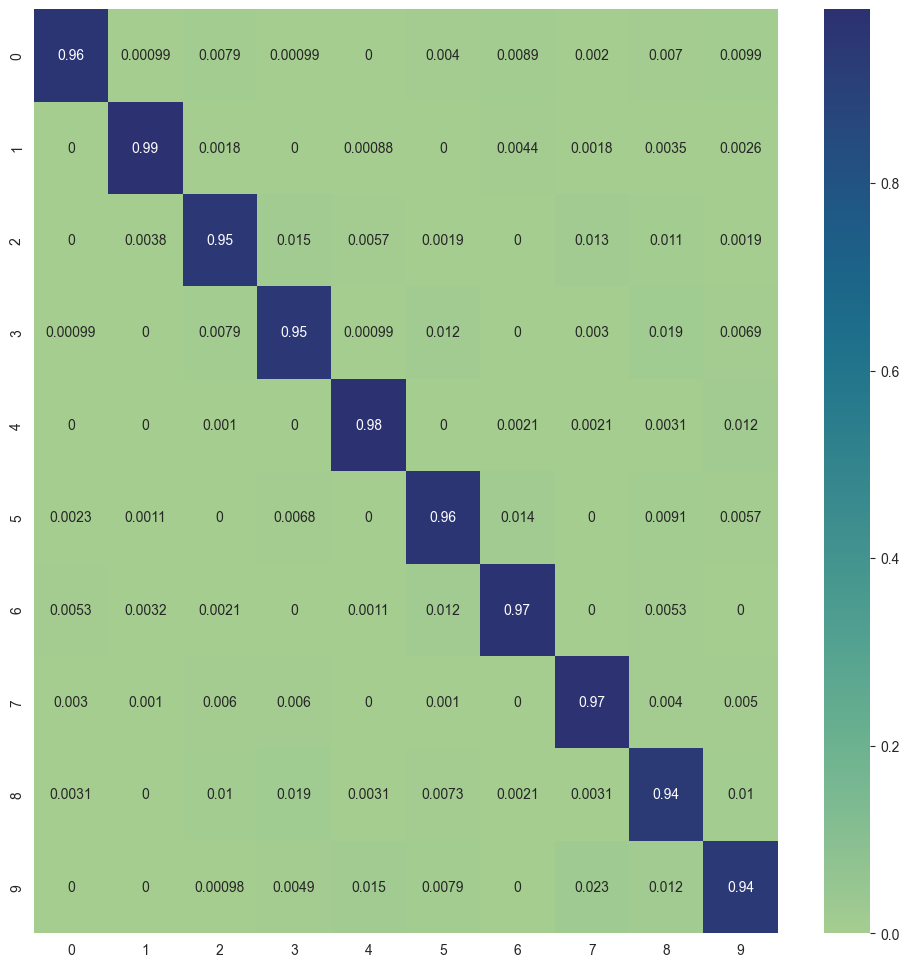

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sn
import pandas as pd
import matplotlib

classes = [str(i) for i in range(10)]

acc_test_train , y_true_, y_pred_ = accuracy(snn,testloader)
y_pred_ = torch.stack(y_pred_).reshape(-1)
y_true_ = torch.stack(y_true_).reshape(-1)

# Build confusion matrix
cf_matrix = confusion_matrix(y_true_, y_pred_)
df_cm = pd.DataFrame(cf_matrix / np.sum(cf_matrix, axis=1)[:, None], index = [i for i in classes],
                    columns = [i for i in classes])
matplotlib.rcParams.update({'font.size': 10})
plt.figure(figsize = (12,12))
sn.heatmap(df_cm, annot=True, cmap="crest")

np.savez(
    'confusion_matrix_SNN_NMNIST_32_32_TWO_LAYER_POS_POL.npz',
    cm=cf_matrix,
)

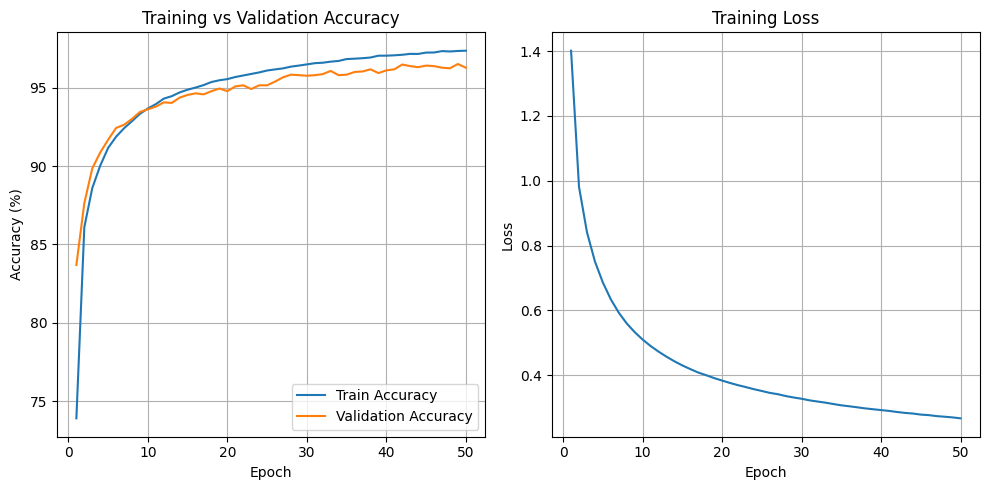

In [24]:
import matplotlib.pyplot as plt

epochs = range(1, len(acc_train_history) + 1)

plt.figure(figsize=(10,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs, acc_train_history, label='Train Accuracy')
plt.plot(epochs, acc_val_history, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs, avg_loss, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=300)
plt.show()